<a href="https://colab.research.google.com/github/Semere-Mesfin-Gebresilassie/Semere-Mesfin-Gebresilassie/blob/main/ERA_Data_Analysis_and_Visualizations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import all necessary libararies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# 1. Load data(ERA Design Chart Datasets)

file_path = "/content/ERA Datasets(FOF).xlsx"
df = pd.read_excel(file_path)

In [3]:
# Display basic information of the dataset

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (210, 10)

First 5 rows:
   CBR_Value (%)  ESAL_Value (millions) Chart_Type     Asphalt_Type  \
0            2.0                   0.20         A1  DST or Ottaseal   
1            2.0                   0.50         A1  DST or Ottaseal   
2            2.0                   1.10         A1  DST or Ottaseal   
3            2.0                   2.25         A1  DST or Ottaseal   
4            2.0                   4.50         A1  DST or Ottaseal   

                      Base_Type          Subbase_Type  Asphalt_Thickness(mm)  \
0  GB2/3(Granular Base 2 and 3)  Granular Subbase(GS)                      0   
1  GB2/3(Granular Base 2 and 3)  Granular Subbase(GS)                      0   
2  GB2/3(Granular Base 2 and 3)  Granular Subbase(GS)                      0   
3  GB2/3(Granular Base 2 and 3)  Granular Subbase(GS)                      0   
4          GB1(Granular Base 1)  Granular Subbase(GS)                      0   

   Base_Thickness (mm)  Subbase_Thickness (mm)  Capp

In [4]:
# 2. Data cleaning & preparation

# Rename columns for easier access

df.columns = df.columns.str.strip()
df.rename(columns={
    'CBR_Value (%)': 'CBR',
    'ESAL_Value (millions)': 'ESAL',
    'Chart_Type': 'Chart',
    'Asphalt_Type': 'AsphaltType'
}, inplace=True)

# Ensure thickness columns are numeric

thick_cols = ['Asphalt_Thickness(mm)', 'Base_Thickness (mm)',
              'Subbase_Thickness (mm)', 'Capping_Layer_Thickness (mm)']
for col in thick_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Create a flag for presence of each layer (1 if >0 else 0)

for col in thick_cols:
    layer = col.split('_')[0]
    df[f'{layer}_Present'] = (df[col] > 0).astype(int)



In [5]:
# 3. Summary statistics

print("\n=== Summary Statistics ===")
print(df[['CBR', 'ESAL'] + thick_cols].describe())



=== Summary Statistics ===
              CBR        ESAL  Asphalt_Thickness(mm)  Base_Thickness (mm)  \
count  210.000000  210.000000             210.000000           210.000000   
mean    12.666667    9.505143              40.000000           196.547619   
std     10.654237   12.888046              51.041779            58.228309   
min      2.000000    0.200000               0.000000           110.000000   
25%      3.500000    1.100000               0.000000           150.000000   
50%      8.500000    4.500000               0.000000           190.000000   
75%     22.500000   13.500000              90.000000           220.000000   
max     31.000000   65.000000             150.000000           400.000000   

       Subbase_Thickness (mm)  Capping_Layer_Thickness (mm)  
count              210.000000                    210.000000  
mean               148.928571                    112.023810  
std                 94.251875                    121.769546  
min                  0.000000 

In [6]:
# Check unique chart types

print("\nChart Types:", df['Chart'].unique())
print("Asphalt Types:", df['AsphaltType'].unique())


Chart Types: ['A1' 'A2' 'A3' 'B1' 'C1' 'C2' 'D1']
Asphalt Types: ['DST or Ottaseal' 'AC_Surface' 'Wearing and Binder Course ']


In [7]:
# 4. Analysis: How do thicknesses vary with CBR & ESAL?

# Group by CBR and show mean thickness per layer

print("\n=== Mean Thickness by CBR ===")
print(df.groupby('CBR')[thick_cols].mean().round(1))



=== Mean Thickness by CBR ===
      Asphalt_Thickness(mm)  Base_Thickness (mm)  Subbase_Thickness (mm)  \
CBR                                                                        
2.0                    40.0                201.7                   205.7   
3.5                    40.0                201.7                   192.1   
6.0                    40.0                197.4                   178.6   
11.0                   40.0                198.1                   175.0   
22.5                   40.0                184.6                   132.9   
31.0                   40.0                195.7                     9.3   

      Capping_Layer_Thickness (mm)  
CBR                                 
2.0                          311.4  
3.5                          203.6  
6.0                          121.4  
11.0                          14.3  
22.5                           0.0  
31.0                          21.4  


In [8]:
# ESAL is continuous; create bins for analysis

df['ESAL_bin'] = pd.cut(df['ESAL'], bins=[0,1,2,5,10,20,40,70],
                        labels=['0-1','1-2','2-5','5-10','10-20','20-40','40-70'])

print("\n=== Mean Thickness by ESAL Range ===")
print(df.groupby('ESAL_bin')[thick_cols].mean().round(1))


=== Mean Thickness by ESAL Range ===
          Asphalt_Thickness(mm)  Base_Thickness (mm)  Subbase_Thickness (mm)  \
ESAL_bin                                                                       
0-1                         0.0                147.9                   128.5   
1-2                        12.5                174.0                   140.6   
2-5                        12.5                186.5                   177.6   
5-10                       48.6                216.3                   154.8   
10-20                      68.0                232.7                   140.0   
20-40                     120.0                227.9                   130.2   
40-70                      90.0                215.0                   154.2   

          Capping_Layer_Thickness (mm)  
ESAL_bin                                
0-1                              104.9  
1-2                              110.4  
2-5                              119.8  
5-10                             114

/tmp/ipykernel_1690/3213127666.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('ESAL_bin')[thick_cols].mean().round(1))


In [9]:
# 5. Visualization setup

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

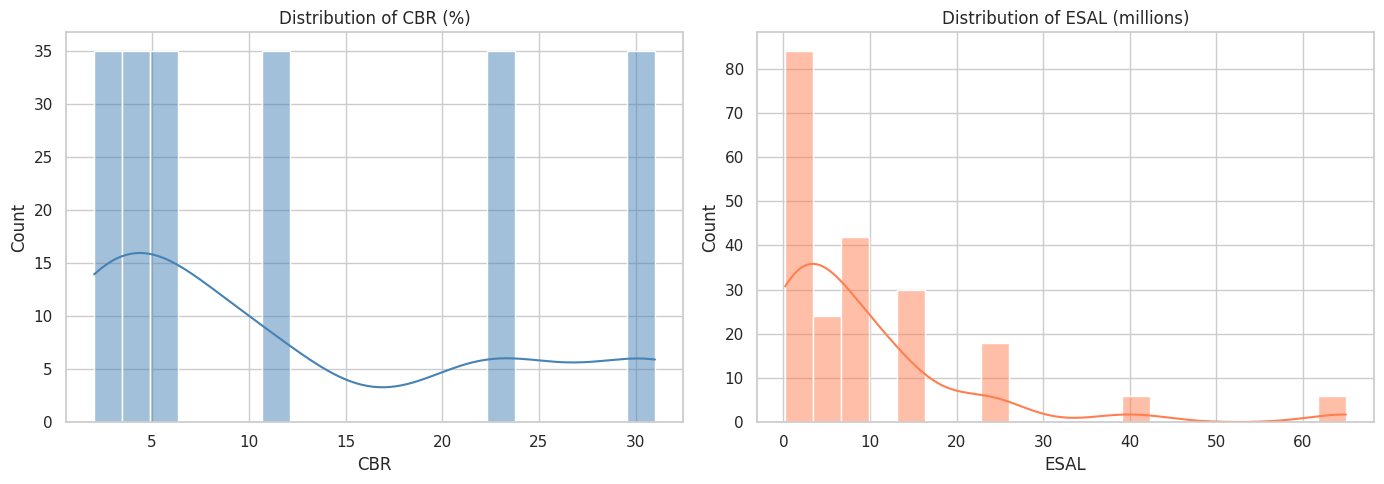

In [10]:
# 5.1 Distribution of CBR and ESAL

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(df['CBR'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of CBR (%)')
sns.histplot(df['ESAL'], bins=20, kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution of ESAL (millions)')
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

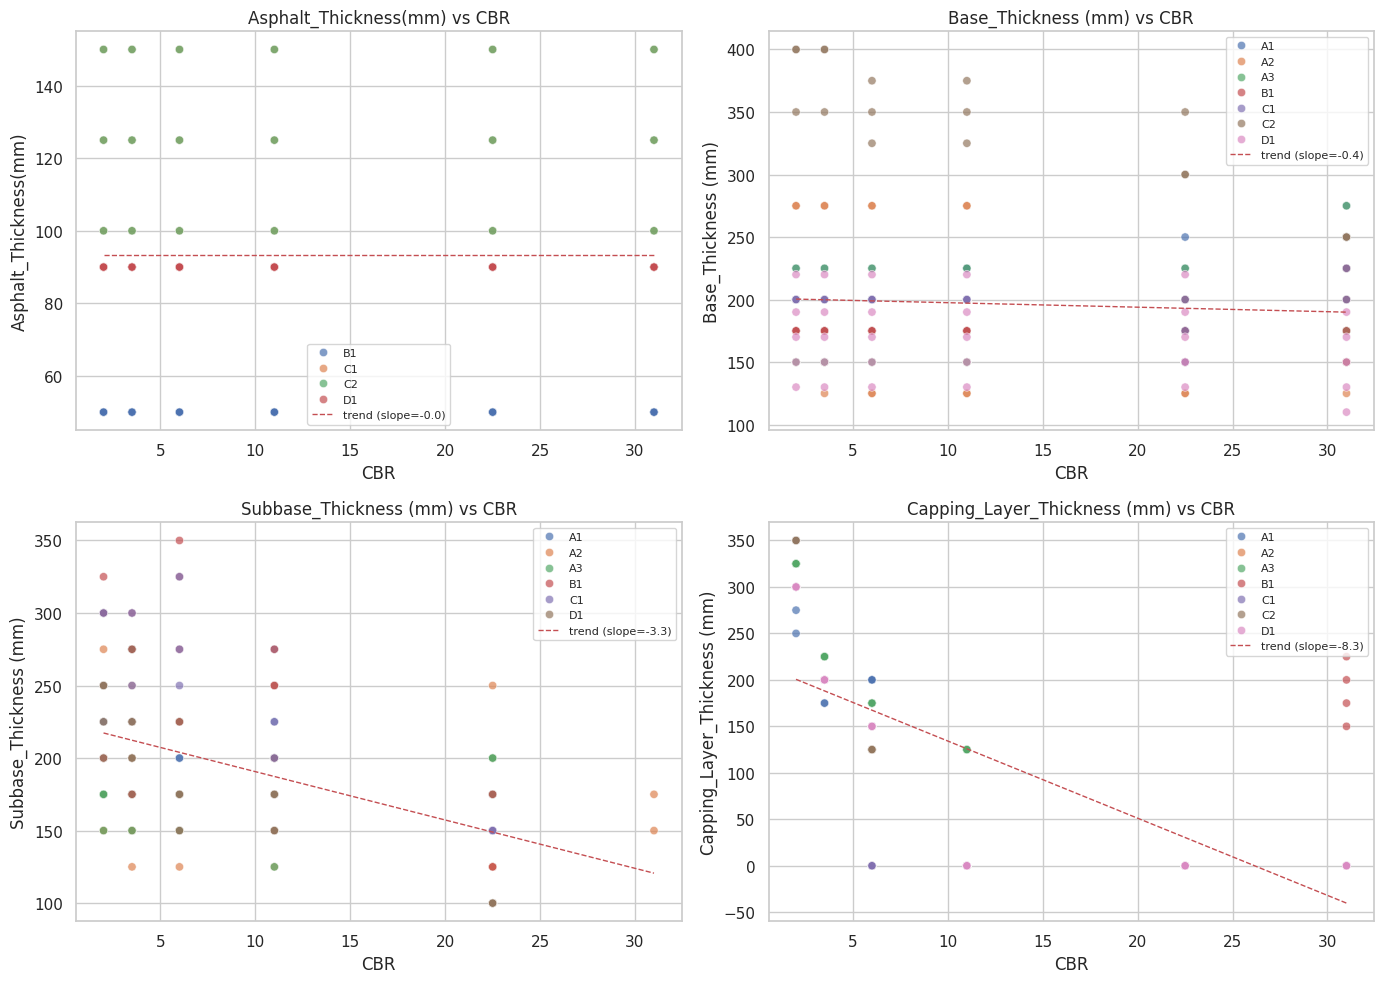

In [11]:
# 5.2 Thickness vs CBR (scatter + regression line)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
targets = zip(thick_cols, axes.flatten())
for col, ax in targets:
    # Filter out zeros for clearer trend (optional)
    data = df[df[col] > 0] if 'Capping' not in col else df
    sns.scatterplot(data=data, x='CBR', y=col, hue='Chart', alpha=0.7, ax=ax)
    # Add trend line
    z = np.polyfit(data['CBR'], data[col], 1)
    p = np.poly1d(z)
    ax.plot(data['CBR'].sort_values(), p(data['CBR'].sort_values()),
            "r--", linewidth=1, label=f'trend (slope={z[0]:.1f})')
    ax.set_title(f'{col} vs CBR')
    ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('thickness_vs_CBR.png', dpi=150)
plt.show()

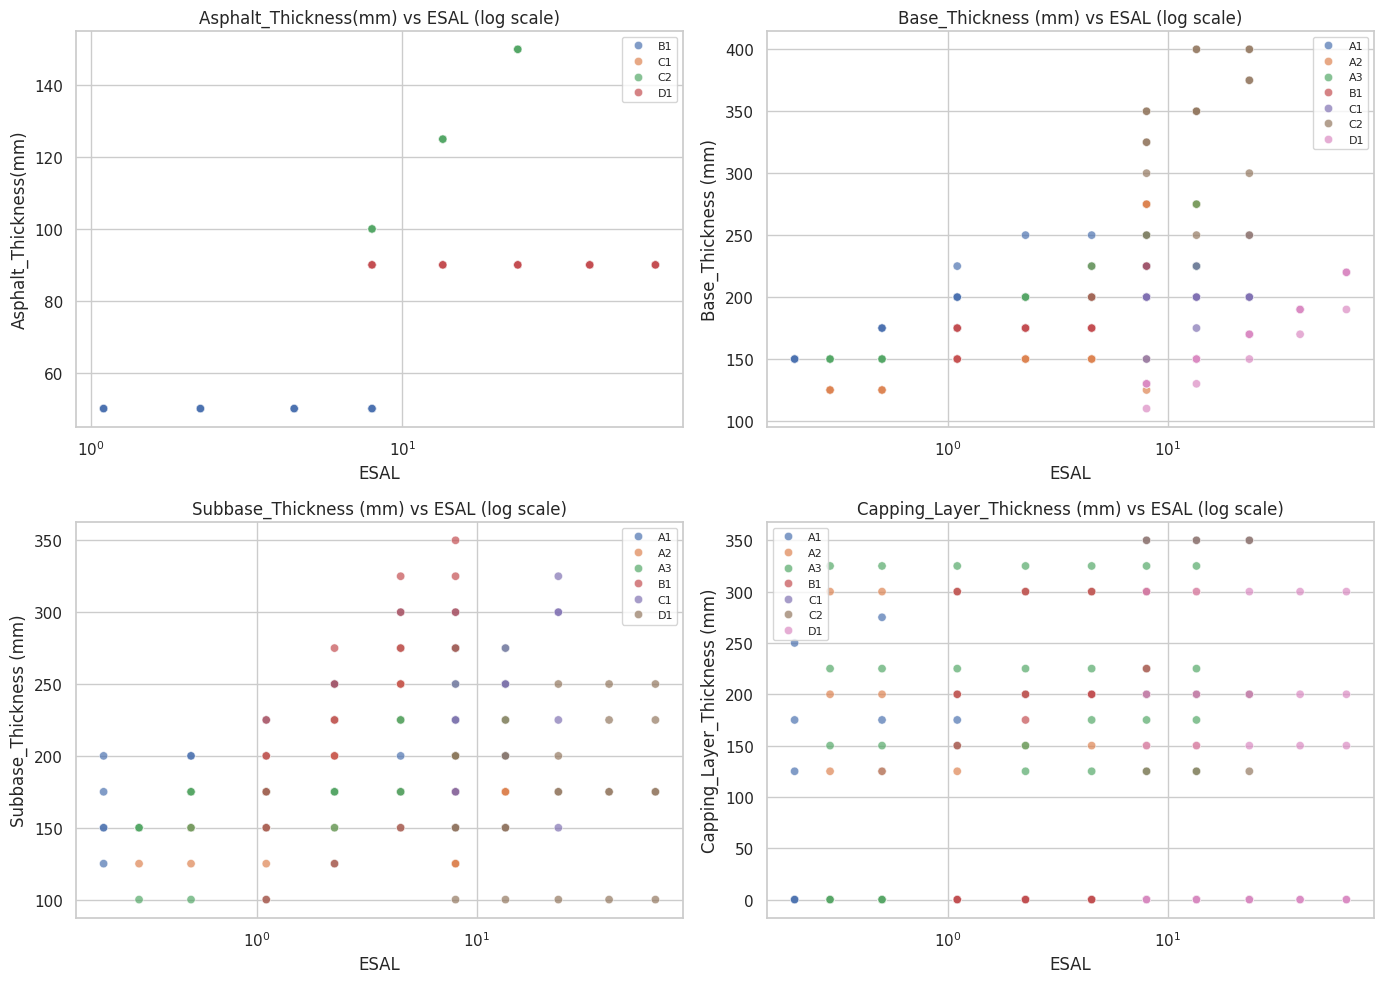

In [12]:
# 5.3 Thickness vs ESAL (log scale for ESAL)

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for col, ax in zip(thick_cols, axes.flatten()):
    data = df[df[col] > 0] if 'Capping' not in col else df
    sns.scatterplot(data=data, x='ESAL', y=col, hue='Chart', alpha=0.7, ax=ax)
    ax.set_xscale('log')
    ax.set_title(f'{col} vs ESAL (log scale)')
    ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('thickness_vs_ESAL.png', dpi=150)
plt.show()

/tmp/ipykernel_1690/2123082851.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Chart', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_1690/2123082851.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Chart', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_1690/2123082851.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Chart', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_1690/2123082851.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in 

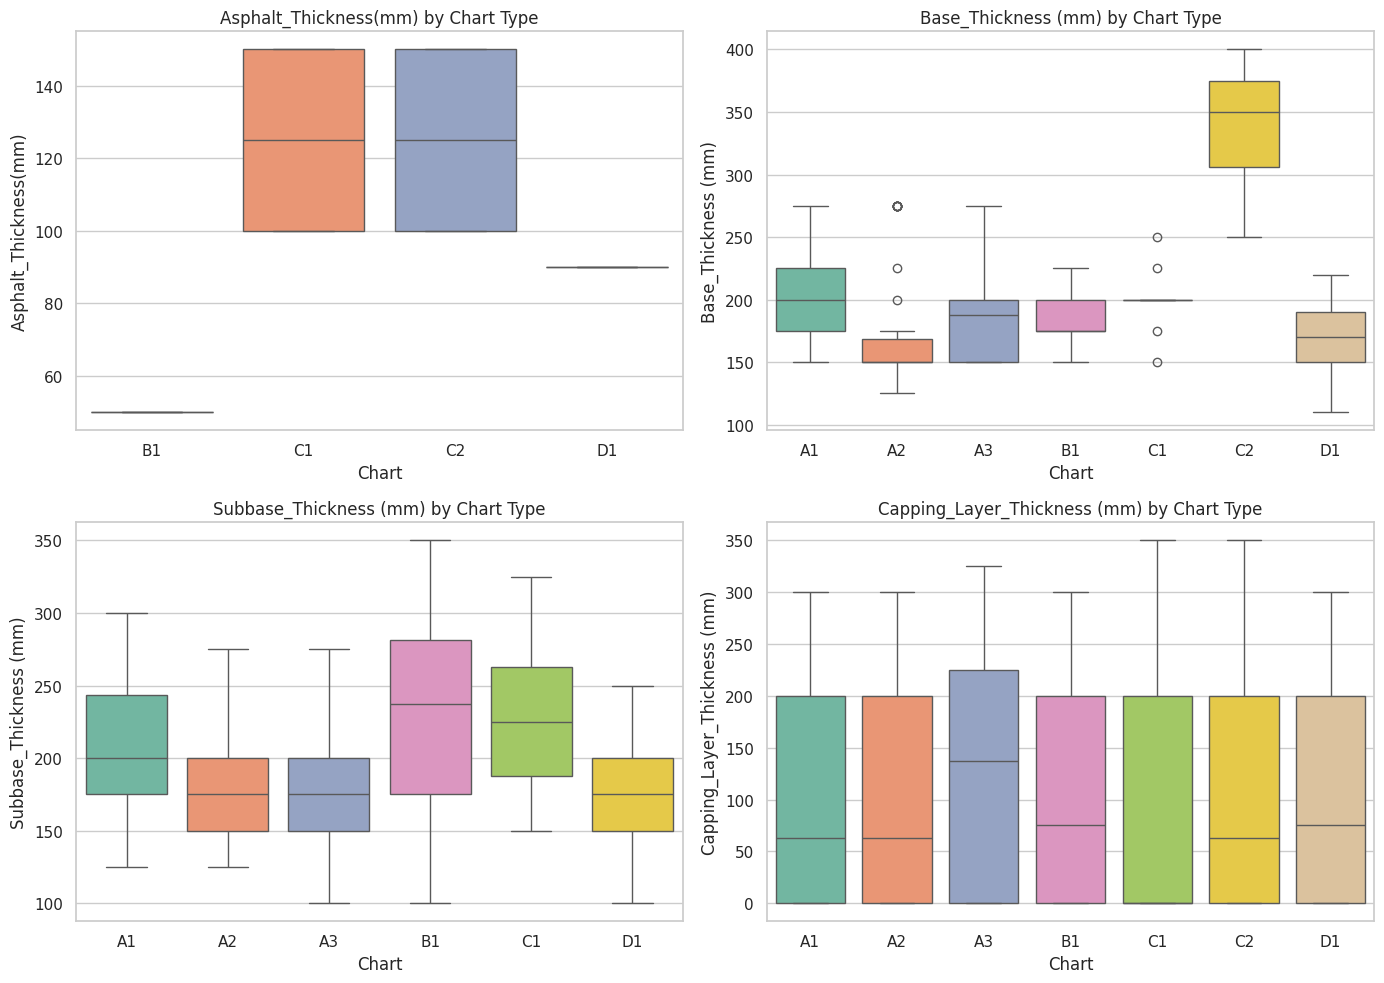

In [13]:
# 5.4 Boxplots of layer thickness by Chart Type

fig, axes = plt.subplots(2, 2, figsize=(14,10))
for col, ax in zip(thick_cols, axes.flatten()):

    # Only include positive thicknesses for boxplot

    plot_df = df[df[col] > 0] if 'Capping' not in col else df
    sns.boxplot(data=plot_df, x='Chart', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} by Chart Type')
plt.tight_layout()
plt.savefig('boxplots_by_chart.png', dpi=150)
plt.show()

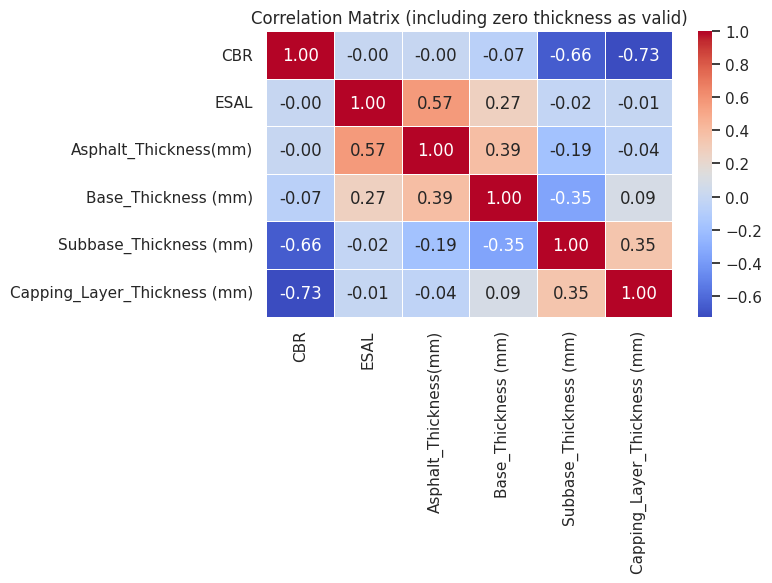

In [14]:
# 5.5 Heatmap: correlation between CBR, ESAL and thicknesses (only positive)

corr_cols = ['CBR', 'ESAL'] + thick_cols
corr_df = df[corr_cols].copy()

# For thickness columns, we can keep zeros (they are valid)

corr_matrix = corr_df.corr(method='pearson')
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (including zero thickness as valid)')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [15]:
# 6. Advanced: Layer presence analysis

presence_cols = ['Asphalt_Present', 'Base_Present', 'Subbase_Present', 'Capping_Present']
presence_summary = df.groupby('Chart')[presence_cols].mean().round(2) * 100
print("\n=== Percentage of designs that include each layer (by Chart Type) ===")
print(presence_summary)


=== Percentage of designs that include each layer (by Chart Type) ===
       Asphalt_Present  Base_Present  Subbase_Present  Capping_Present
Chart                                                                 
A1                 0.0         100.0             83.0             50.0
A2                 0.0         100.0             88.0             50.0
A3                 0.0         100.0             83.0             60.0
B1               100.0         100.0             83.0             50.0
C1               100.0         100.0             83.0             33.0
C2               100.0         100.0              0.0             50.0
D1               100.0         100.0             83.0             50.0


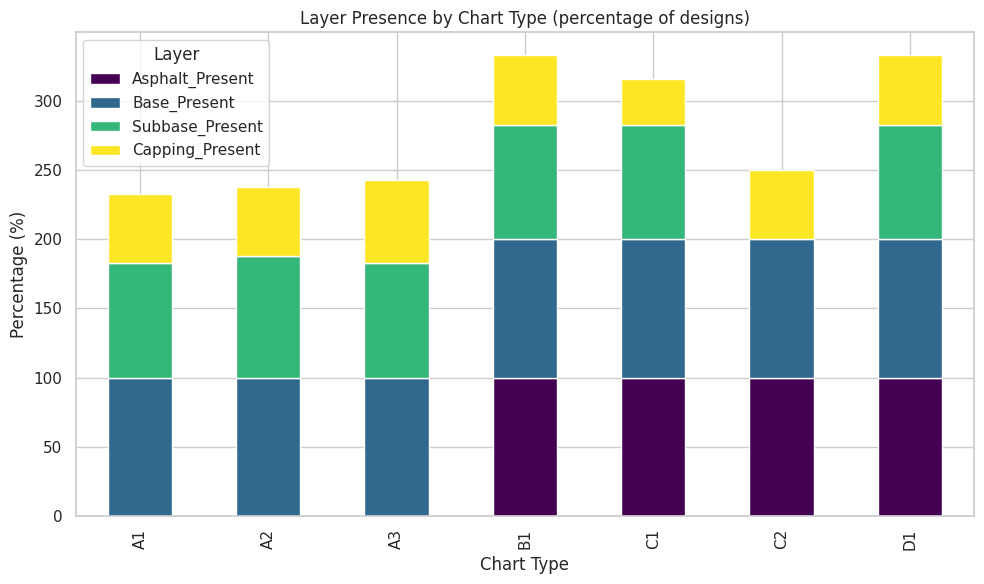

In [16]:
# Stacked bar chart of layer presence

presence_summary.plot(kind='bar', stacked=True, figsize=(10,6), colormap='viridis')
plt.title('Layer Presence by Chart Type (percentage of designs)')
plt.ylabel('Percentage (%)')
plt.xlabel('Chart Type')
plt.legend(title='Layer')
plt.tight_layout()
plt.savefig('layer_presence.png', dpi=150)
plt.show()


In [17]:
# 7. Export summary statistics to CSV

summary = df.groupby(['CBR', 'Chart'])[thick_cols].agg(['mean', 'std', 'count'])
summary.to_csv('pavement_thickness_summary.csv')
print("\nSummary table saved as 'pavement_thickness_summary.csv'")


Summary table saved as 'pavement_thickness_summary.csv'


**Key Insights from the Analysis**



*   CBR & ESAL drive thickness: Higher CBR (stronger subgrade) allows thinner
layers; higher ESAL (more traffic) demands thicker layers.
*   Chart Types represent different pavement structural configurations:

A1–A3: Thin asphalt (mostly surface treatments)

B1: AC surface (50 mm) with granular or stabilised bases

C1–C2: Wearing & binder courses (100–150 mm asphalt) and heavy-duty bases

D1: Cement/lime stabilised bases with moderate asphalt (90 mm)

Zero values are meaningful: For example, capping layer disappears when CBR ≥ 11% or for many C2/D1 designs.

